In [41]:
import pandas as pd

# Read JSON directly from Downloads (forward slashes avoid escape issues)
df = pd.read_json("C:/Users/user/Downloads/CUADv1.json")

print(df.shape)
df.head()

(510, 2)


,version,data
0,aok_v1.0,{'title': 'LIMEENERGYCO_09_09_1999-EX-10-DISTR...
1,aok_v1.0,"{'title': 'WHITESMOKE,INC_11_08_2011-EX-10.26-..."
2,aok_v1.0,{'title': 'LohaCompanyltd_20191209_F-1_EX-10.1...
3,aok_v1.0,{'title': 'CENTRACKINTERNATIONALINC_10_29_1999...
4,aok_v1.0,{'title': 'NELNETINC_04_08_2020-EX-1-JOINT FIL...


In [42]:
print(df.columns.tolist())

['version', 'data']


In [44]:
df.iloc[0]

version                                             aok_v1.0
data       {'title': 'LIMEENERGYCO_09_09_1999-EX-10-DISTR...
Name: 0, dtype: object

In [45]:
first_contract = df.iloc[0]["data"]

print(type(first_contract))
print(first_contract.keys())

<class 'dict'>
dict_keys(['title', 'paragraphs'])


In [46]:
rows = []

for contract in df["data"]:
    title = contract["title"]

    for para in contract["paragraphs"]:
        text = para["context"]

        for qa in para["qas"]:
            rows.append({
                "Contract": title,
                "Category": qa["question"],
                "Clause_Text": text[:200]
            })

analysis_df = pd.DataFrame(rows)

analysis_df.head()

,Contract,Category,Clause_Text
0,LIMEENERGYCO_09_09_1999-EX-10-DISTRIBUTOR AGRE...,Highlight the parts (if any) of this contract ...,EXHIBIT 10.6\n\n ...
1,LIMEENERGYCO_09_09_1999-EX-10-DISTRIBUTOR AGRE...,Highlight the parts (if any) of this contract ...,EXHIBIT 10.6\n\n ...
2,LIMEENERGYCO_09_09_1999-EX-10-DISTRIBUTOR AGRE...,Highlight the parts (if any) of this contract ...,EXHIBIT 10.6\n\n ...
3,LIMEENERGYCO_09_09_1999-EX-10-DISTRIBUTOR AGRE...,Highlight the parts (if any) of this contract ...,EXHIBIT 10.6\n\n ...
4,LIMEENERGYCO_09_09_1999-EX-10-DISTRIBUTOR AGRE...,Highlight the parts (if any) of this contract ...,EXHIBIT 10.6\n\n ...


In [47]:
analysis_df.to_csv("cuad_cleaned.csv", index=False)

print("Saved successfully!")

Saved successfully!


In [48]:
print(first_contract["title"])

LIMEENERGYCO_09_09_1999-EX-10-DISTRIBUTOR AGREEMENT


In [49]:
paragraphs = first_contract["paragraphs"]

print("Total Paragraphs:", len(paragraphs))

Total Paragraphs: 1


In [50]:
paragraphs[0].keys()

dict_keys(['qas', 'context'])

In [51]:
print(paragraphs[0]["context"][:1000])

EXHIBIT 10.6

                              DISTRIBUTOR AGREEMENT

         THIS  DISTRIBUTOR  AGREEMENT (the  "Agreement")  is made by and between Electric City Corp.,  a Delaware  corporation  ("Company")  and Electric City of Illinois LLC ("Distributor") this 7th day of September, 1999.

                                    RECITALS

         A. The  Company's  Business.  The Company is  presently  engaged in the business  of selling an energy  efficiency  device,  which is  referred to as an "Energy  Saver"  which may be improved  or  otherwise  changed  from its present composition (the "Products").  The Company may engage in the business of selling other  products  or  other  devices  other  than  the  Products,  which  will be considered  Products if Distributor  exercises its options pursuant to Section 7 hereof.

         B. Representations.  As an inducement to the Company to enter into this Agreement,  the  Distributor  has  represented  that  it has or  will  have  the facil

In [52]:
qas = paragraphs[0]["qas"]

print(len(qas))

41


In [53]:
qas[0]

{'answers': [{'text': 'DISTRIBUTOR AGREEMENT', 'answer_start': 44}],
 'id': 'LIMEENERGYCO_09_09_1999-EX-10-DISTRIBUTOR AGREEMENT__Document Name',
 'question': 'Highlight the parts (if any) of this contract related to "Document Name" that should be reviewed by a lawyer. Details: The name of the contract',
 'is_impossible': False}

In [54]:
categories = set()

for contract in df["data"]:
    for para in contract["paragraphs"]:
        for qa in para["qas"]:
            categories.add(qa["question"])

print("Total Categories:", len(categories))

sorted(categories)

Total Categories: 41


['Highlight the parts (if any) of this contract related to "Affiliate License-Licensee" that should be reviewed by a lawyer. Details: Does the contract contain a license grant to a licensee (incl. sublicensor) and the affiliates of such licensee/sublicensor?',
 'Highlight the parts (if any) of this contract related to "Affiliate License-Licensor" that should be reviewed by a lawyer. Details: Does the contract contain a license grant by affiliates of the licensor or that includes intellectual property of affiliates of the licensor?\xa0',
 'Highlight the parts (if any) of this contract related to "Agreement Date" that should be reviewed by a lawyer. Details: The date of the contract',
 'Highlight the parts (if any) of this contract related to "Anti-Assignment" that should be reviewed by a lawyer. Details: Is consent or notice required of a party if the contract is assigned to a third party?',
 'Highlight the parts (if any) of this contract related to "Audit Rights" that should be reviewe

In [55]:
from collections import Counter

counter = Counter()

for contract in df["data"]:
    for para in contract["paragraphs"]:
        for qa in para["qas"]:
            counter[qa["question"]] += 1

counter.most_common(20)

[('Highlight the parts (if any) of this contract related to "Document Name" that should be reviewed by a lawyer. Details: The name of the contract',
  510),
 ('Highlight the parts (if any) of this contract related to "Parties" that should be reviewed by a lawyer. Details: The two or more parties who signed the contract',
  510),
 ('Highlight the parts (if any) of this contract related to "Agreement Date" that should be reviewed by a lawyer. Details: The date of the contract',
  510),
 ('Highlight the parts (if any) of this contract related to "Effective Date" that should be reviewed by a lawyer. Details: The date when the contract is effective\xa0',
  510),
 ('Highlight the parts (if any) of this contract related to "Expiration Date" that should be reviewed by a lawyer. Details: On what date will the contract\'s initial term expire?',
  510),
 ('Highlight the parts (if any) of this contract related to "Renewal Term" that should be reviewed by a lawyer. Details: What is the renewal term

In [56]:
import pandas as pd

rows = []

for contract in df["data"]:
    title = contract["title"]

    for para in contract["paragraphs"]:
        text = para["context"]

        for qa in para["qas"]:
            rows.append({
                "contract": title,
                "category": qa["question"],
                "text": text[:300]
            })

analysis_df = pd.DataFrame(rows)

analysis_df.head()

,contract,category,text
0,LIMEENERGYCO_09_09_1999-EX-10-DISTRIBUTOR AGRE...,Highlight the parts (if any) of this contract ...,EXHIBIT 10.6\n\n ...
1,LIMEENERGYCO_09_09_1999-EX-10-DISTRIBUTOR AGRE...,Highlight the parts (if any) of this contract ...,EXHIBIT 10.6\n\n ...
2,LIMEENERGYCO_09_09_1999-EX-10-DISTRIBUTOR AGRE...,Highlight the parts (if any) of this contract ...,EXHIBIT 10.6\n\n ...
3,LIMEENERGYCO_09_09_1999-EX-10-DISTRIBUTOR AGRE...,Highlight the parts (if any) of this contract ...,EXHIBIT 10.6\n\n ...
4,LIMEENERGYCO_09_09_1999-EX-10-DISTRIBUTOR AGRE...,Highlight the parts (if any) of this contract ...,EXHIBIT 10.6\n\n ...


In [57]:
print("Total Contracts:", len(df))
print("Total Categories:", len(categories))
print("Total Annotations:", len(analysis_df))

Total Contracts: 510
Total Categories: 41
Total Annotations: 20910


In [58]:
analysis_df["category"].value_counts().head(10)

category
Highlight the parts (if any) of this contract related to "Document Name" that should be reviewed by a lawyer. Details: The name of the contract                                                                                                                                                                                                                                    510
Highlight the parts (if any) of this contract related to "Parties" that should be reviewed by a lawyer. Details: The two or more parties who signed the contract                                                                                                                                                                                                                   510
Highlight the parts (if any) of this contract related to "Agreement Date" that should be reviewed by a lawyer. Details: The date of the contract                                                                                                 

In [59]:
%pip install matplotlib

Note: you may need to restart the kernel to use updated packages.


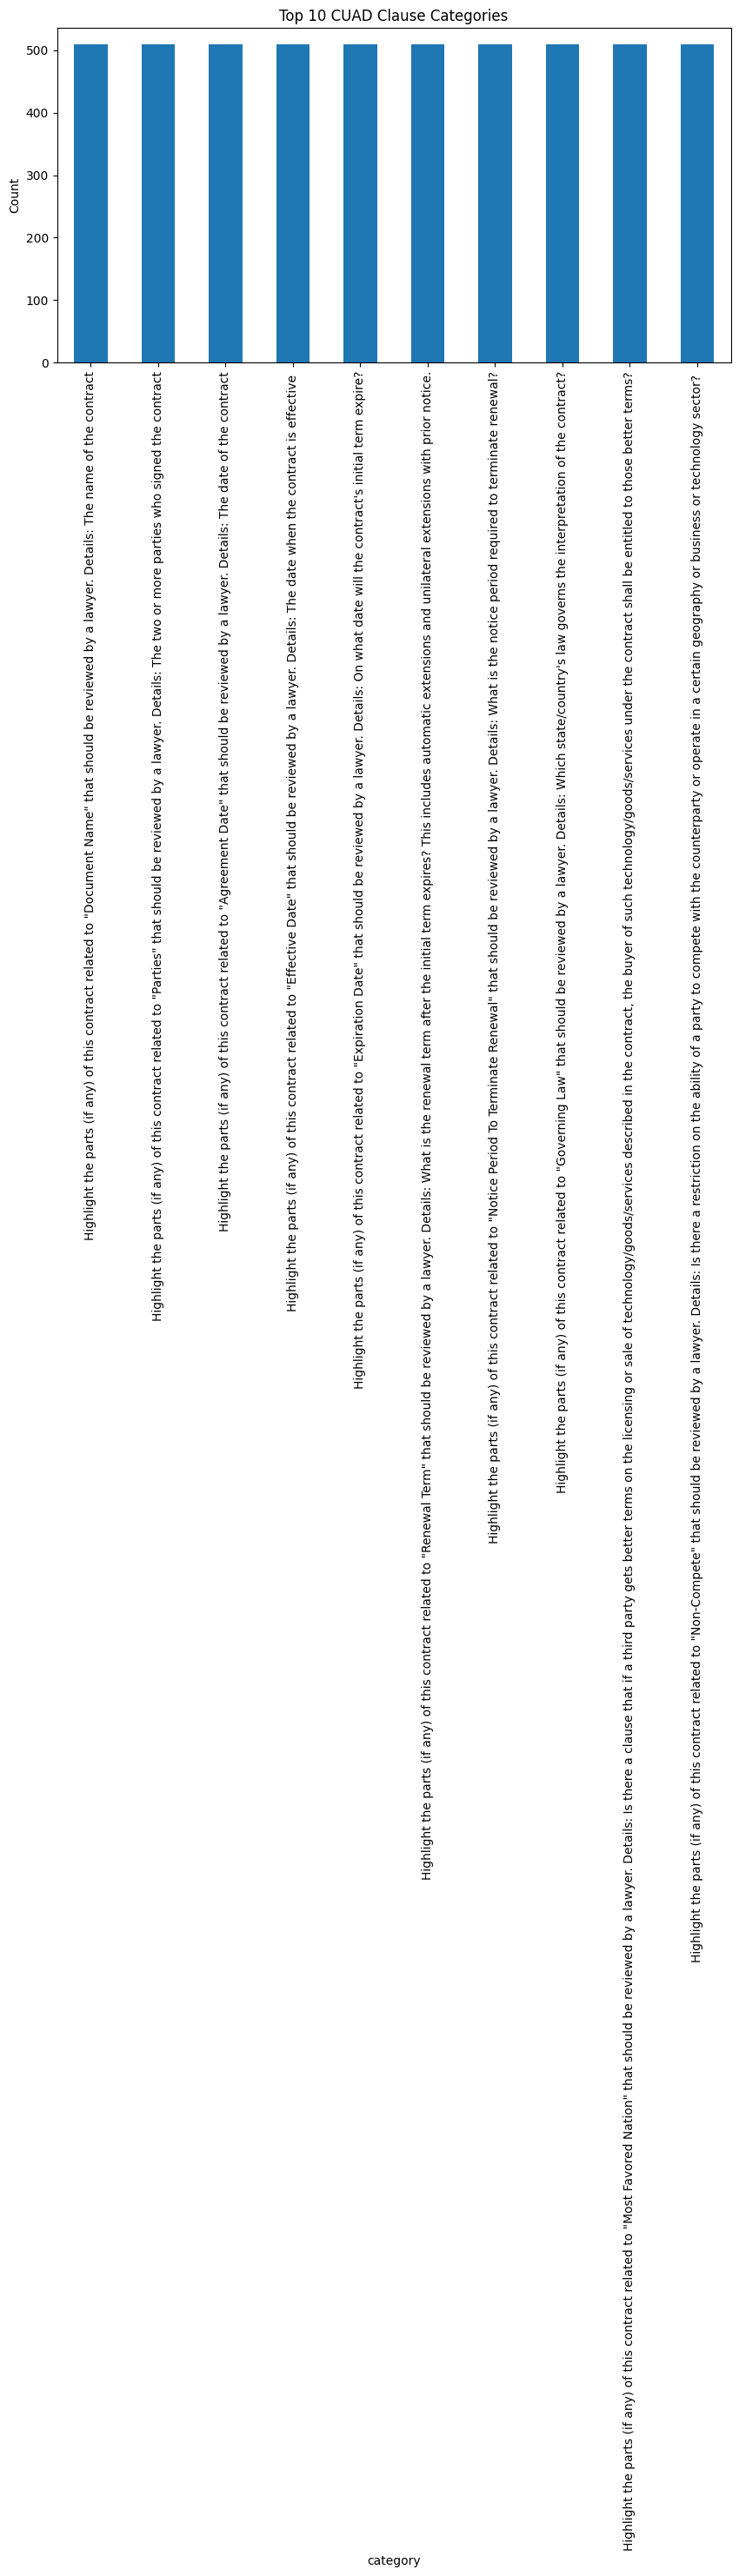

In [60]:
import matplotlib.pyplot as plt

top_categories = analysis_df["category"].value_counts().head(10)

plt.figure(figsize=(10,5))
top_categories.plot(kind="bar")
plt.title("Top 10 CUAD Clause Categories")
plt.ylabel("Count")
plt.show()

In [61]:
summary = pd.DataFrame({
    "Category": analysis_df["category"].value_counts().index,
    "Count": analysis_df["category"].value_counts().values
})

summary.to_csv("cuad_category_summary.csv", index=False)

print("Summary exported successfully.")

Summary exported successfully.
